# Business Understanding

## Background

Global Superstore is a multinational retail company that sells a wide range of products across different markets, regions, and customer segments. As the company continues to grow, understanding sales performance, product profitability, and regional trends becomes increasingly important for making data-driven business decisions.

This project analyzes the Global Superstore dataset to uncover meaningful insights into sales, profit, product performance, and operational efficiency. The findings aim to support better strategic decisions and provide recommendations to improve overall business performance.

## Business Problem

Despite having extensive transactional data, the company lacks clear visibility into several key business questions, such as:

- How have sales and profit changed over time?
- Which product categories and sub-categories contribute the most to revenue and profit?
- Which customer segments generate the highest business value?
- Which markets and regions perform the best?
- How do discount strategies affect profitability?
- Does shipping performance have an impact on profit?

Answering these questions will help identify business opportunities, improve operational efficiency, and support strategic decision-making.

## Project Objectives

The main objectives of this project are:

- Analyze overall sales and profit performance over time.
- Identify the best-performing product categories and sub-categories.
- Analyze customer segment performance.
- Evaluate sales performance across markets, regions, countries, and states.
- Assess the relationship between discount strategies and profitability.
- Analyze shipping performance and its impact on business outcomes.
- Generate actionable business insights and recommendations.
- Build an interactive Power BI dashboard to communicate key findings.

# Data Understanding


In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
path = kagglehub.dataset_download("thuandao/superstore-sales-analytics")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'superstore-sales-analytics' dataset.
Path to dataset files: /kaggle/input/superstore-sales-analytics
['SuperStoreOrders - SuperStoreOrders.csv']


In [3]:
file_path = os.path.join(path, "SuperStoreOrders - SuperStoreOrders.csv")
df = pd.read_csv(file_path)

In [4]:
df.shape

(51290, 21)

In [5]:
df.head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011
5,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",55,2,0.1,15.342,1.80,Medium,2011
6,CA-2011-1510,2/1/2011,6/1/2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.0,3.120,24.10,Medium,2011
7,IN-2011-79397,3/1/2011,3/1/2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.412,125.32,Critical,2011
8,ID-2011-80230,3/1/2011,9/1/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.464,107.10,Low,2011
9,IZ-2011-4680,3/1/2011,7/1/2011,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.320,81.26,High,2011


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


# Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%d/%m/%Y")
df['ship_date'] = pd.to_datetime(df['ship_date'], format="%d/%m/%Y")
df["sales"] = (df["sales"].str.replace(",", "", regex=False).astype(float))
print(df.dtypes)

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object


In [10]:
print("Negative Sales :", (df["sales"] < 0).sum())
print("Negative Quantity :", (df["quantity"] < 0).sum())
print("Negative Shipping Cost :", (df["shipping_cost"] < 0).sum())

Negative Sales : 0
Negative Quantity : 0
Negative Shipping Cost : 0


In [11]:
categorical_columns = [
    "category",
    "sub_category",
    "segment",
    "region",
    "market",
    "ship_mode"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


category
['Office Supplies' 'Furniture' 'Technology']

sub_category
['Storage' 'Supplies' 'Paper' 'Furnishings' 'Machines' 'Appliances'
 'Copiers' 'Chairs' 'Tables' 'Bookcases' 'Phones' 'Accessories' 'Labels'
 'Art' 'Envelopes' 'Fasteners' 'Binders']

segment
['Consumer' 'Home Office' 'Corporate']

region
['Africa' 'Oceania' 'EMEA' 'North' 'Canada' 'Southeast Asia' 'Central'
 'South' 'Caribbean' 'North Asia' 'East' 'West' 'Central Asia']

market
['Africa' 'APAC' 'EMEA' 'EU' 'Canada' 'LATAM' 'US']

ship_mode
['Standard Class' 'Second Class' 'Same Day' 'First Class']


In [12]:
invalid_dates = df[df["ship_date"] < df["order_date"]]

print(f"Invalid records: {len(invalid_dates)}")

Invalid records: 0


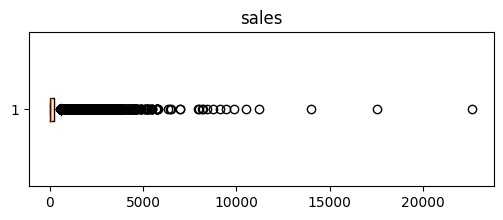

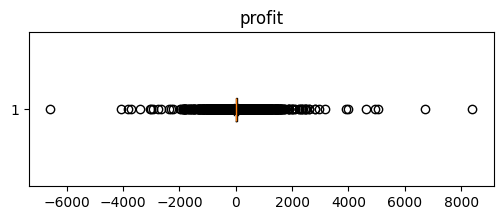

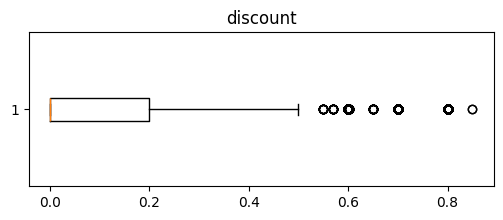

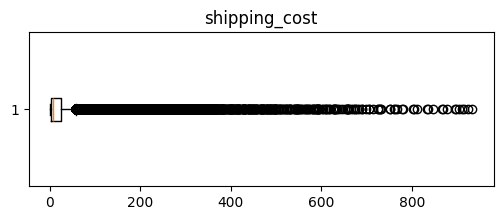

In [13]:
import matplotlib.pyplot as plt

columns = ["sales", "profit", "discount", "shipping_cost"]

for col in columns:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

In [14]:
df[df["sales"] == 0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40017,US-2014-102288,2014-06-20,2014-06-24,Standard Class,Zuschuss Carroll,Consumer,Texas,United States,US,Central,...,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.0,1,0.8,-1.11,0.01,Medium,2014


# Feature Engineering

## Date Features

In [15]:
df["month_number"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%B")
df["quarter"] = df["order_date"].dt.quarter

df[["order_date","year", "month_number", "month_name", "quarter"]].head()

,order_date,year,month_number,month_name,quarter
0,2011-01-01,2011,1,January,1
1,2011-01-01,2011,1,January,1
2,2011-01-01,2011,1,January,1
3,2011-01-01,2011,1,January,1
4,2011-01-01,2011,1,January,1


## Shipping Features

In [16]:
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

## Financial Features

In [17]:
df["profit_margin"] = np.where(df["sales"] != 0, (df["profit"] / df["sales"]) * 100, np.nan)

# EDA

## Overview

In [18]:
overview = pd.DataFrame({"Metric": ["Total Orders", "Total Customers", "Total Products", "Countries", "Markets", "Categories", "Sub-Categories"],
    "Value": [df["order_id"].nunique(), df["customer_name"].nunique(), df["product_name"].nunique(), df["country"].nunique(), df["market"].nunique(), df["category"].nunique(), df["sub_category"].nunique()]
})
overview

,Metric,Value
0,Total Orders,25035
1,Total Customers,795
2,Total Products,3788
3,Countries,147
4,Markets,7
5,Categories,3
6,Sub-Categories,17


## Overall Performance

### Sales Trend

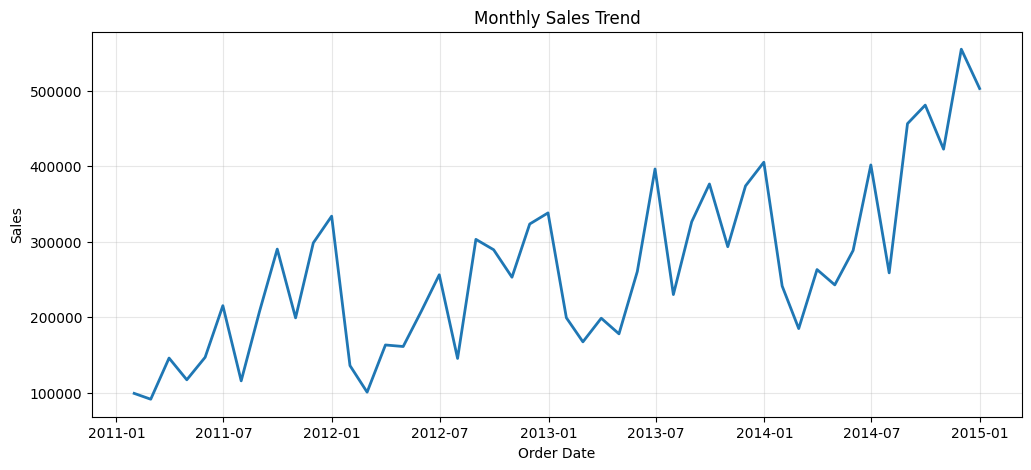

In [19]:
monthly_sales = (df.groupby(pd.Grouper(key="order_date", freq="ME"))["sales"].sum().reset_index())

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["order_date"], monthly_sales["sales"], linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

#### observation

*   Monthly sales fluctuate throughout the observed period.
*   Overall, sales show an upward trend from 2011 to 2014.
*   Sales reached their highest level in late 2014.
*   Several noticeable declines occurred after periods of high sales, indicating seasonal or promotional effects.

#### insight

The company's sales have grown consistently over the four-year period despite short-term fluctuations. The strong increase in sales during 2014 indicates business expansion or improved market performance. However, the recurring peaks and declines suggest that sales may be influenced by seasonal demand, promotional campaigns, or purchasing cycles. Further analysis is required to identify the factors driving these fluctuations.



### Profit Trend

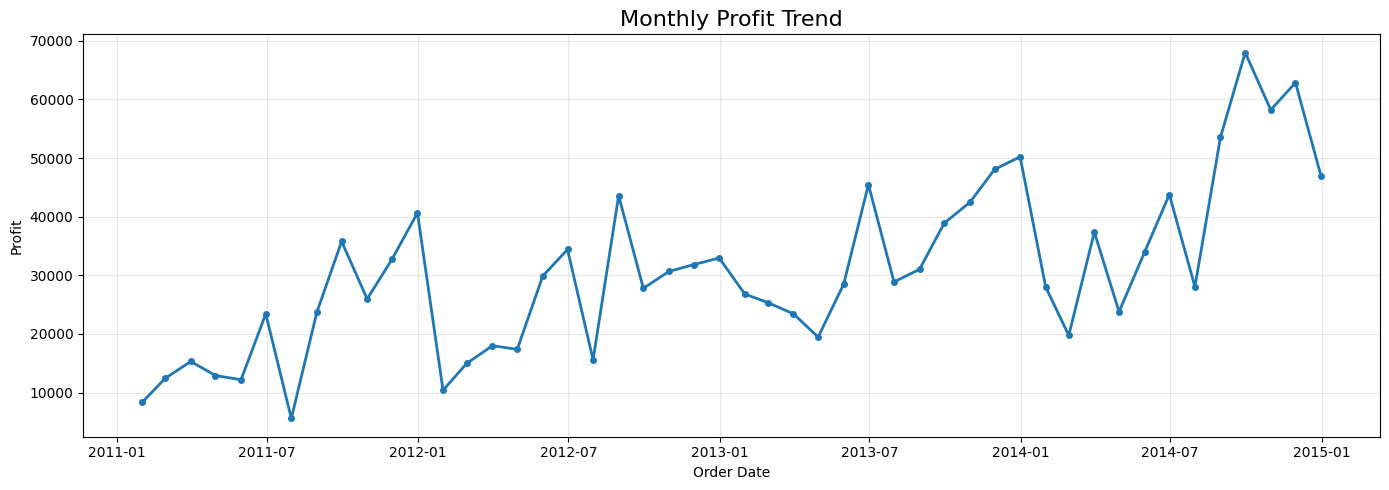

In [20]:
monthly_profit = (df.groupby(pd.Grouper(key="order_date", freq="ME"))["profit"].sum().reset_index())

plt.figure(figsize=(14,5))
plt.plot(monthly_profit["order_date"], monthly_profit["profit"], marker="o", linewidth=2, markersize=4)
plt.title("Monthly Profit Trend", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Profit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### observation

- Monthly profit fluctuated throughout the analysis period.
- Despite short-term fluctuations, the overall profit trend increased from 2011 to 2014.
- Profit reached its highest level during the last quarter of 2014.
- Several months experienced noticeable declines in profit after periods of strong performance.

#### insight

The company maintained positive profitability throughout the four-year period while showing a clear long-term growth trend. The significant increase in profit during 2014 suggests improved business performance. However, the recurring fluctuations indicate that profitability is influenced by factors beyond sales volume alone, such as product mix, discounts, or operational costs. Additional analysis is required to identify the key drivers affecting monthly profit.

### Sales vs Profit

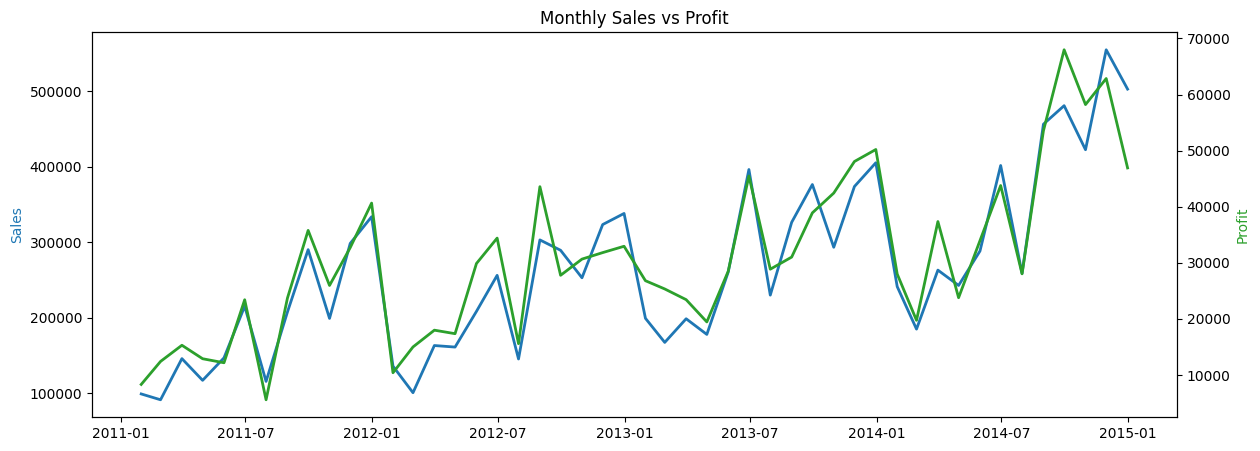

In [21]:
monthly_performance = (df.groupby(pd.Grouper(key="order_date", freq="ME")).agg({"sales": "sum", "profit": "sum"}).reset_index())

fig, ax1 = plt.subplots(figsize=(14,5))

# Sales
ax1.plot(monthly_performance["order_date"], monthly_performance["sales"], color="tab:blue", linewidth=2, label="Sales")
ax1.set_ylabel("Sales", color="tab:blue")

# Profit
ax2 = ax1.twinx()

ax2.plot(monthly_performance["order_date"], monthly_performance["profit"], color="tab:green", linewidth=2, label="Profit")
ax2.set_ylabel("Profit", color="tab:green")
plt.title("Monthly Sales vs Profit")
plt.show()

#### observation
- Monthly sales and profit generally move in the same direction throughout the analysis period.
- Periods of increasing sales are typically accompanied by higher profit.
- Despite this positive relationship, the growth rates of sales and profit are not always proportional.
- The strongest performance for both metrics occurred during the second half of 2014.
#### insight
Overall, the company demonstrates a positive relationship between sales and profit, indicating that higher sales generally contribute to higher profitability. However, the difference in growth patterns suggests that factors such as discounts, product mix, and operational costs influence profit beyond sales volume alone. Therefore, increasing sales should not be the only business objective; maintaining healthy profit margins is equally important.

## Product Analysis

### Sales by Category

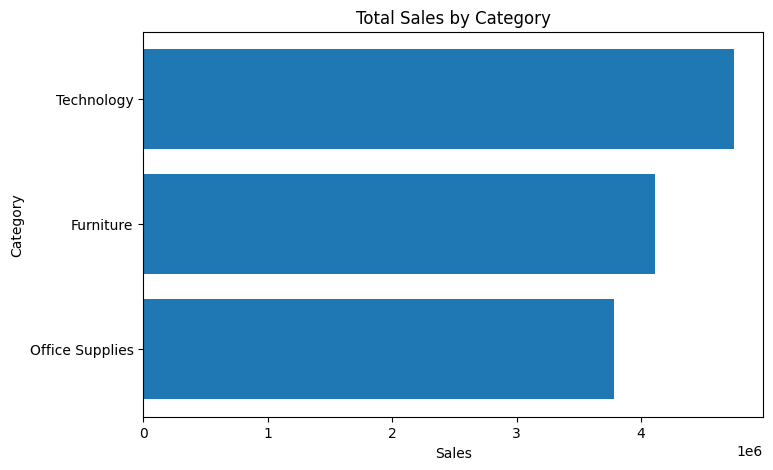

In [22]:
category_sales = (df.groupby("category")["sales"].sum().sort_values(ascending=False).reset_index())
category_sales

plt.figure(figsize=(8,5))
plt.barh(category_sales["category"], category_sales["sales"])
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.show()

##### observation
- Technology generated the highest total sales among all product categories.
- Furniture ranked second in terms of sales, followed by Office Supplies.
- Although Office Supplies contains the largest number of sub-categories, its total sales were the lowest.
#### insight
Technology is the company's primary revenue driver and should remain a strategic focus for inventory management and marketing initiatives. The lower sales contribution from Office Supplies suggests an opportunity to improve product positioning or promotional strategies within this category.

### Profit by Category

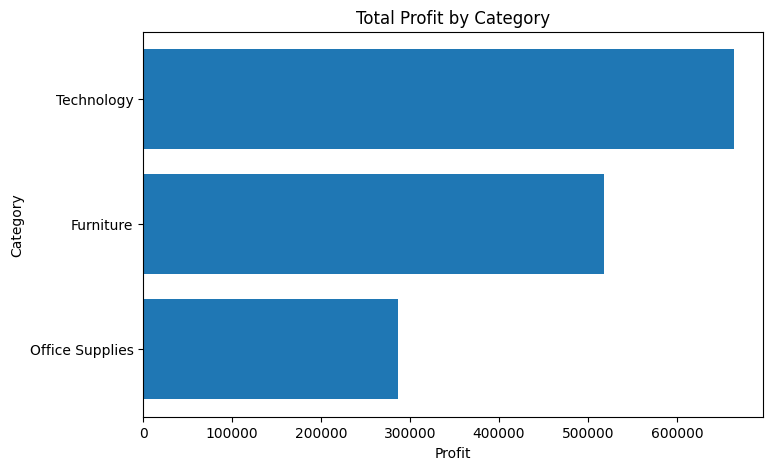

In [23]:
category_profit = (df.groupby("category")["profit"].sum().sort_values(ascending=False).reset_index())

plt.figure(figsize=(8,5))
plt.barh(category_sales["category"], category_profit["profit"])
plt.title("Total Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.show()

#### observation

- Technology generated the highest total profit among all product categories.
- Furniture ranked second in total profit.
- Office Supplies generated the lowest total profit despite containing the largest number of product sub-categories.

#### insight

Technology is the company's strongest-performing category in terms of profitability, making it a key driver of business growth. Although Office Supplies includes a wide variety of products, it contributes the lowest overall profit, suggesting opportunities to improve pricing strategies, optimize product mix, or reduce excessive discounting within this category.

### Sales by Sub-Category

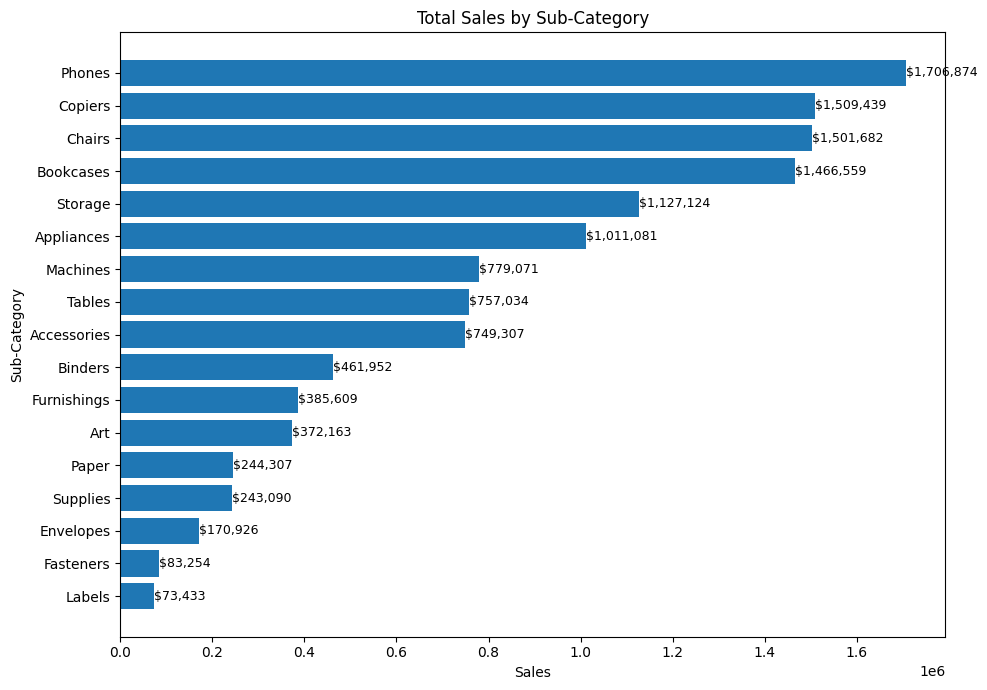

In [24]:
subcategory_sales = (df.groupby("sub_category", as_index=False)["sales"].sum().sort_values("sales", ascending=False))

plt.figure(figsize=(10,7))
bars = plt.barh(subcategory_sales["sub_category"], subcategory_sales["sales"])
plt.title("Total Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### observation
- Phones generated the highest total sales, followed by Copiers, Chairs, and Bookcases.
- The top five sub-categories contributed a significantly larger portion of total sales compared to the remaining sub-categories.
- Labels and Fasteners recorded the lowest sales among all sub-categories.
#### insight
Sales are concentrated in a small number of sub-categories, particularly Phones and Copiers. These products appear to be the primary revenue drivers and should remain a strategic focus for inventory planning and marketing campaigns.

### Profit by Sub-Category

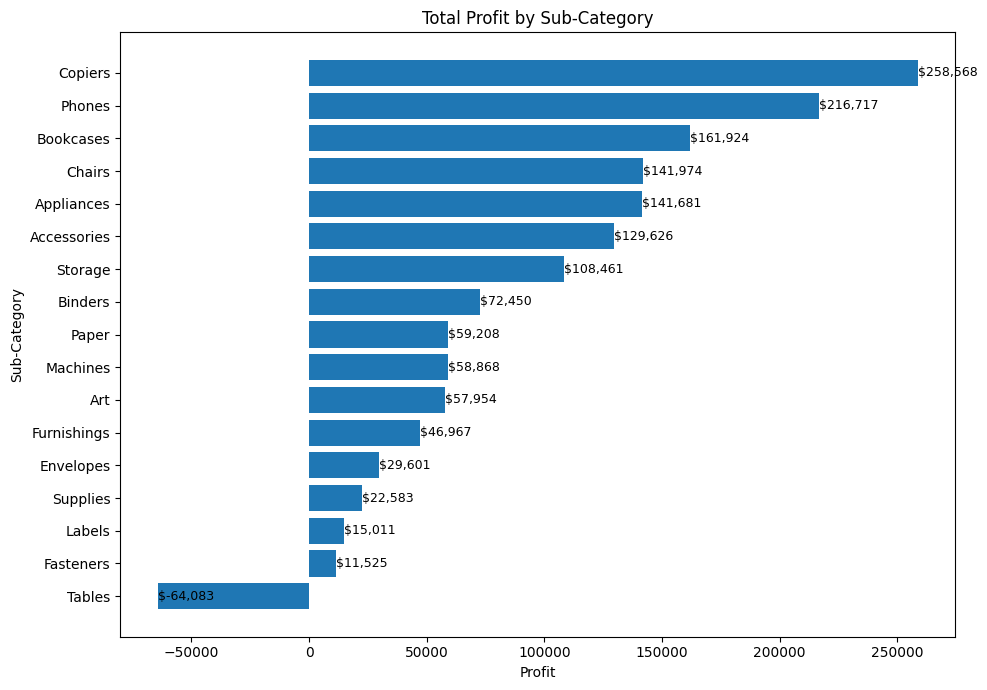

In [25]:
subcategory_profit = (df.groupby("sub_category", as_index=False)["profit"].sum().sort_values("profit", ascending=False))

plt.figure(figsize=(10,7))
bars = plt.barh(subcategory_profit["sub_category"], subcategory_profit["profit"])
plt.title("Total Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### observation
- Copiers generated the highest total profit, followed by Phones and Bookcases.
- Most sub-categories generated positive profit.
- Tables was the only sub-category that recorded an overall loss.
#### insight

Although several sub-categories generated strong profits, Tables consistently operated at a loss despite producing substantial sales. This indicates potential issues related to pricing strategy, discount levels, or procurement costs that require further investigation.

### High Sales, Low Profit Analysis

In [26]:
subcategory_summary = (df.groupby("sub_category").agg(Sales=("sales","sum"), Profit=("profit","sum"), Quantity=("quantity","sum")))

subcategory_summary["Profit Margin (%)"] = (subcategory_summary["Profit"] / subcategory_summary["Sales"]) * 100

subcategory_summary = subcategory_summary.sort_values("Sales", ascending=False)
subcategory_summary

,Sales,Profit,Quantity,Profit Margin (%)
sub_category,,,,
Phones,1706874.0,216717.00580,11870,12.696720
Copiers,1509439.0,258567.54818,7454,17.130043
Chairs,1501682.0,141973.79750,12336,9.454318
Bookcases,1466559.0,161924.41950,8310,11.041112
Storage,1127124.0,108461.48980,16917,9.622853
Appliances,1011081.0,141680.58940,6078,14.012783
Machines,779071.0,58867.87300,4906,7.556163
Tables,757034.0,-64083.38870,3083,-8.465061
Accessories,749307.0,129626.30620,10946,17.299492


#### observation
- Phones generated the highest sales among all product sub-categories.
- Copiers achieved the highest total profit while maintaining a strong profit margin of over 17%.
- Tables generated more than $750K in sales but resulted in an overall loss, making it the only loss-making sub-category.
- Paper recorded the highest profit margin despite contributing relatively low total sales.
#### insight
The analysis shows that high sales do not always translate into high profitability. While Phones and Copiers are the company's primary revenue and profit drivers, Tables reduce overall profitability despite generating substantial revenue. Conversely, Paper demonstrates excellent profitability with a relatively small sales volume, suggesting opportunities to increase sales through targeted promotions without significantly affecting margins.

### Top 10 Product

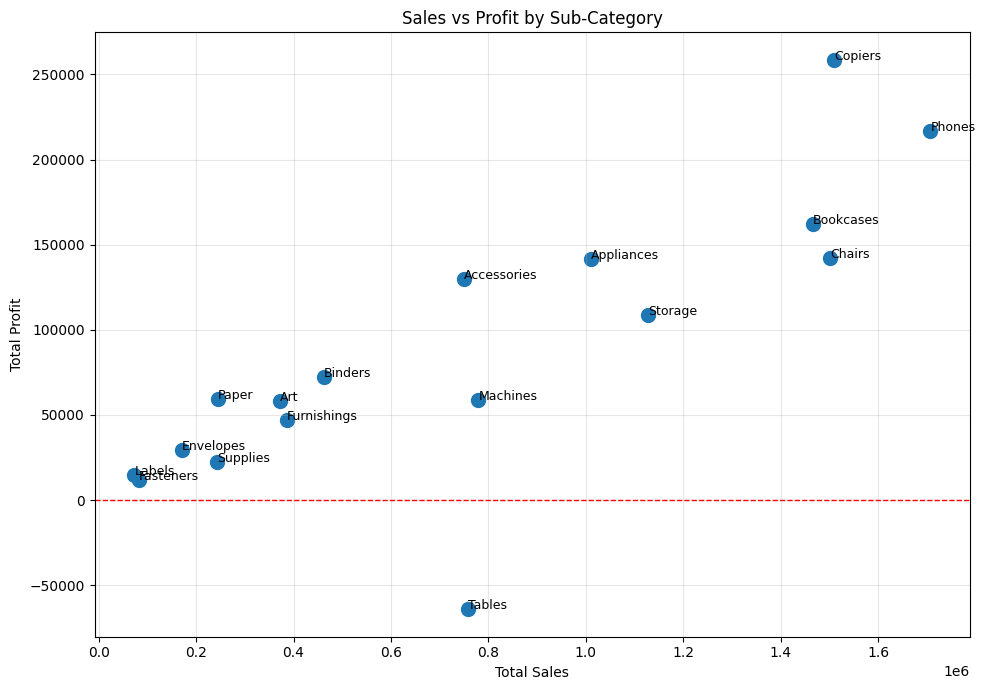

In [27]:
subcategory_summary = (df.groupby("sub_category", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum")))

subcategory_summary

plt.figure(figsize=(10, 7))

plt.scatter(subcategory_summary["Sales"], subcategory_summary["Profit"], s=100)

for _, row in subcategory_summary.iterrows():
    plt.text(row["Sales"], row["Profit"], row["sub_category"], fontsize=9, ha="left")

plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Sales vs Profit by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### observation
- Phones and Copiers are positioned in the high sales–high profit quadrant.
- Tables is the only sub-category with negative profit despite relatively high sales.
- Paper achieves a healthy profit with comparatively lower sales.
- Several sub-categories generate moderate sales while maintaining consistent profitability.
#### insight
The scatter plot highlights that not all high-revenue products generate strong profitability. Tables should be prioritized for pricing and discount evaluation due to its negative profit despite strong sales. Meanwhile, Copiers and Phones represent the company's strongest-performing sub-categories and should remain strategic priorities. Sub-categories such as Paper present growth opportunities because they achieve high profitability relative to their sales volume.

## Customer Analysis

### Sales by segment

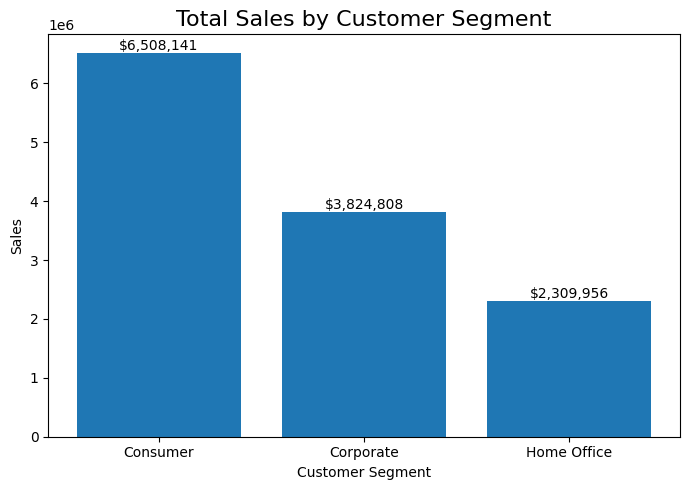

In [28]:
segment_sales = (df.groupby("segment", as_index=False)["sales"].sum().sort_values("sales", ascending=False))

plt.figure(figsize=(7,5))

bars = plt.bar(segment_sales["segment"], segment_sales["sales"])
plt.title("Total Sales by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### observation

- The Consumer segment contributed the highest total sales.
- Corporate customers ranked second.
- Home Office generated the lowest sales among the three customer segments.

#### insight

Consumer customers represent the company's largest revenue source and should remain the primary target for marketing campaigns. However, expanding sales within the Corporate and Home Office segments could diversify revenue sources and reduce dependence on a single customer segment.

### Profit by Segment

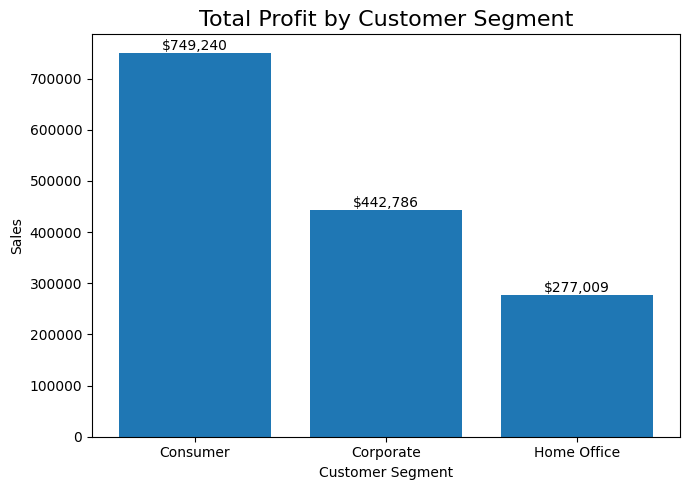

In [29]:
segment_profit = (df.groupby("segment", as_index=False)["profit"].sum().sort_values("profit", ascending=False))

plt.figure(figsize=(7,5))

bars = plt.bar(segment_profit["segment"], segment_profit["profit"])
plt.title("Total Profit by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### observation

- The Consumer segment generated the highest total profit.
- Corporate customers also contributed a significant share of profit.
- Home Office produced the lowest overall profit.

#### insight

The Consumer segment is not only the largest contributor to sales but also the most profitable customer segment. Maintaining customer loyalty within this segment while developing growth strategies for Corporate and Home Office customers could improve overall business performance.

### Top 10 Customer by Sales

In [30]:
top_customers_sales = (df.groupby("customer_name", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum"), Orders=("order_id", "nunique")).sort_values("Sales", ascending=False).head(10))

top_customers_sales

,customer_name,Sales,Profit,Orders
758,Tom Ashbrook,40489.0,6311.97910,30
731,Tamara Chand,37453.0,8672.89890,36
313,Greg Tran,35552.0,5214.13118,34
157,Christopher Conant,35187.0,5603.33370,39
687,Sean Miller,35170.0,-409.70634,28
73,Bart Watters,32315.0,3595.88590,45
558,Natalie Fritzler,31778.0,1542.82110,43
290,Fred Hopkins,30404.0,4609.29112,39
347,Jane Waco,30288.0,6265.84570,40
335,Hunter Lopez,30246.0,7816.56778,24


#### observation

- A small number of customers contributed exceptionally high sales.
- The sales gap between the top-ranked customer and lower-ranked customers is noticeable.

#### insight

The business relies significantly on several high-value customers. Strengthening relationships with these customers through loyalty programs and personalized services may help maintain long-term revenue stability.

### Top 10 Customer by Profit

In [31]:
top_customers_profit = (df.groupby("customer_name", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum"), Orders=("order_id", "nunique")).sort_values("Profit", ascending=False).head(10))

top_customers_profit

,customer_name,Sales,Profit,Orders
731,Tamara Chand,37453.0,8672.89890,36
623,Raymond Buch,29601.0,8453.04950,29
672,Sanjit Chand,26524.0,8205.37990,35
335,Hunter Lopez,30246.0,7816.56778,24
88,Bill Eplett,28480.0,7410.00530,42
323,Harry Marie,28477.0,6958.28640,41
727,Susan Pistek,29020.0,6484.40726,32
542,Mike Gockenbach,23378.0,6458.67620,27
6,Adrian Barton,25125.0,6417.28450,40
758,Tom Ashbrook,40489.0,6311.97910,30


#### observation

- Several top customers generated both high sales and high profit.
- Not every customer with high sales necessarily contributed the highest profit.

#### insight

Customer profitability varies considerably. Sales performance alone should not be used to evaluate customer value, as some customers contribute significantly more profit than others.

### Customer summary

In [32]:
customer_summary = (df.groupby("customer_name", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum"), Orders=("order_id", "nunique")))
customer_summary.describe()

,Sales,Profit,Orders
count,795.000000,795.000000,795.000000
mean,15903.025157,1847.842542,32.393711
std,5209.800805,1544.655073,5.407543
min,3891.000000,-6151.558100,15.000000
25%,12242.500000,984.341310,28.000000
50%,15258.000000,1795.361440,32.000000
75%,18770.500000,2608.656240,36.000000
max,40489.000000,8672.898900,47.000000


## Regional Analysis

### Sales by Market

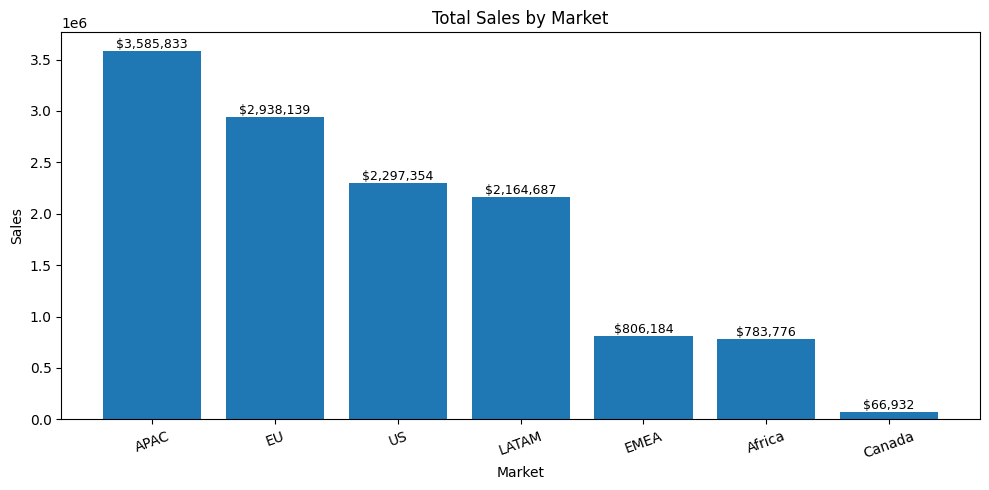

In [33]:
market_sales = (df.groupby("market", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum")).sort_values("Sales", ascending=False))

plt.figure(figsize=(10,5))
bars = plt.bar(market_sales["market"], market_sales["Sales"])
plt.title("Total Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### observation

- Sales are concentrated in a few major markets.
- The leading market contributes a significantly larger share of total revenue than the remaining markets.

#### insight

The company's revenue is heavily influenced by its strongest markets. Maintaining market leadership while identifying growth opportunities in underperforming markets could improve long-term business performance.

### Profit by Market

In [34]:
market_profit = (df.groupby("market", as_index=False).agg(Sales=("sales", "sum"), Profit=("profit", "sum")).sort_values("Profit", ascending=False))

market_profit

,market,Sales,Profit
0,APAC,3585833.0,437577.57900
4,EU,2938139.0,372829.74150
6,US,2297354.0,286397.02170
5,LATAM,2164687.0,221643.48708
1,Africa,783776.0,88871.63100
3,EMEA,806184.0,43897.97100
2,Canada,66932.0,17817.39000


#### observation

- Markets with the highest sales generally also generated the highest profit.
- However, profitability differs across markets, suggesting differences in pricing, product mix, or discount strategies.

#### insight

Market expansion strategies should prioritize not only sales growth but also profitability. High-revenue markets should continue to be optimized, while lower-profit markets require further investigation to improve margins.

### Sales by Region

In [35]:
region_sales = (df.groupby("region", as_index=False).agg(Sales=("sales","sum"), Profit=("profit","sum")).sort_values("Sales", ascending=False))

region_sales

,region,Sales,Profit
3,Central,2822399.0,311403.98164
10,South,1600960.0,140355.76618
7,North,1248192.0,194597.95252
9,Oceania,1100207.0,121666.64200
11,Southeast Asia,884438.0,17852.32900
8,North Asia,848349.0,165578.42100
5,EMEA,806184.0,43897.97100
0,Africa,783776.0,88871.63100
4,Central Asia,752839.0,132480.18700
12,West,725514.0,108418.44890


#### observation

- Sales performance varies considerably across regions.
- A small number of regions contribute the majority of total sales.

#### insight

Regional sales concentration indicates opportunities to strengthen business performance in underperforming regions through localized marketing strategies and product optimization.

### Sales by Country

In [36]:
country_sales = (df.groupby("country", as_index=False).agg(Sales=("sales","sum"),Profit=("profit","sum")).sort_values("Sales", ascending=False).head(10))
country_sales

,country,Sales,Profit
139,United States,2297354.0,286397.02170
6,Australia,925257.0,105484.96300
44,France,858930.0,109029.00300
26,China,700591.0,150683.08500
47,Germany,628857.0,107322.82050
81,Mexico,622620.0,102818.09752
57,India,589664.0,129071.83500
138,United Kingdom,528570.0,111900.15000
58,Indonesia,404887.0,15608.67790
17,Brazil,361098.0,30090.49896


### Top 10 State by Sales

In [37]:
state_sales = (df.groupby("state", as_index=False).agg(Sales=("sales","sum"),Profit=("profit","sum")).sort_values("Sales", ascending=False).head(10))
state_sales

,state,Sales,Profit
311,England,485166.0,99907.7310
192,California,457731.0,76381.3871
435,Ile-de-France,317818.0,44055.9240
703,New York,310914.0,74038.5486
702,New South Wales,270509.0,45273.5140
820,Queensland,238311.0,21608.7540
722,North Rhine-Westphalia,216458.0,42347.8710
983,Texas,170187.0,-25729.3563
867,San Salvador,153648.0,35883.3770
689,National Capital,152185.0,-13066.0845


## Discount Analysis

### Distribution of Discount

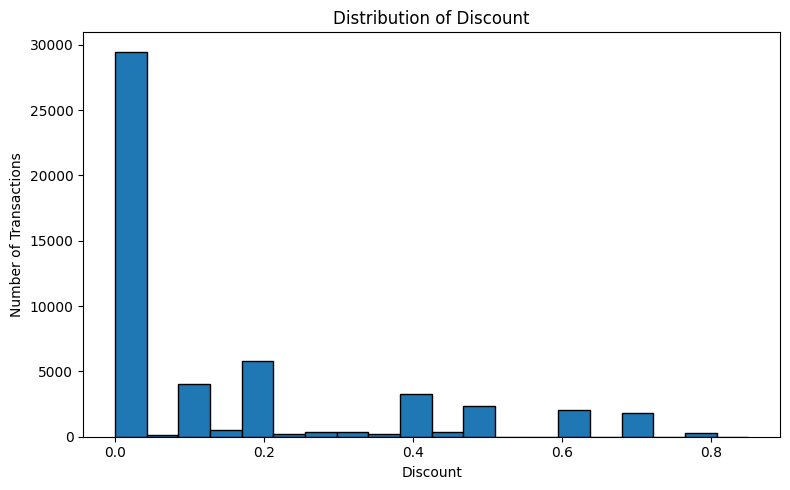

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    df["discount"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

#### observation

- Most transactions received little or no discount.
- High discount levels were relatively uncommon.

#### insight

The company generally follows a low-discount pricing strategy, applying large discounts only in selected transactions.

### Discount vs Profit

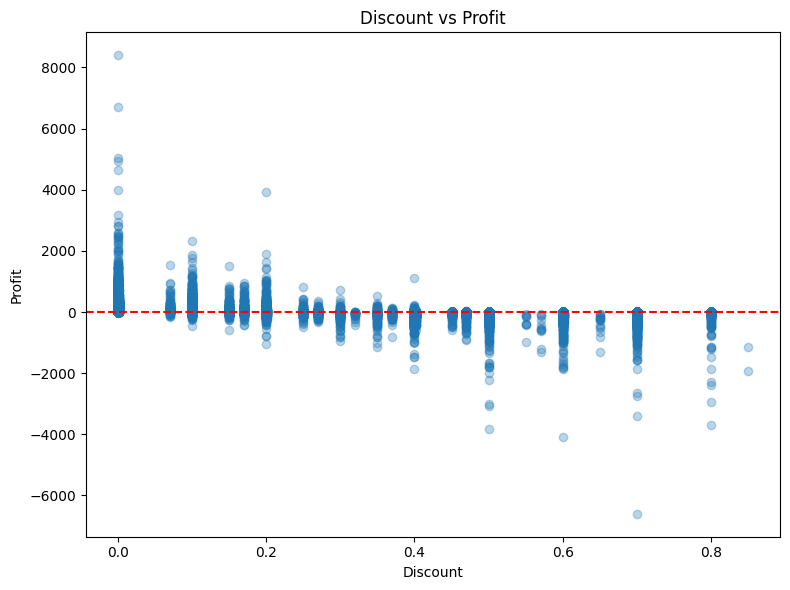

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.3
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

#### observation

- Higher discount levels are associated with greater variability in profit.
- Negative profits become more frequent as discount levels increase.
#### insight

Aggressive discount strategies increase the likelihood of unprofitable transactions. Discount policies should be carefully evaluated to balance sales growth and profitability.


### Average Profit by Discount

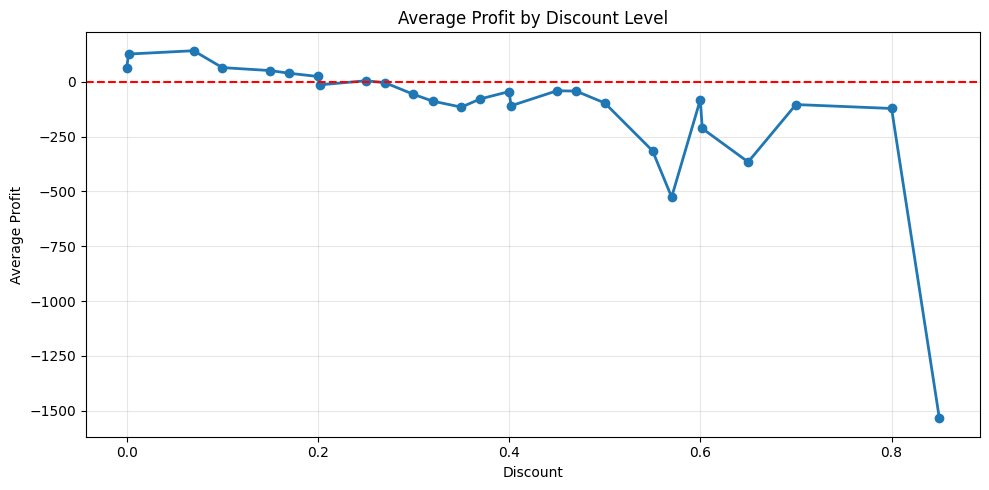

In [40]:
discount_profit = (
    df.groupby("discount", as_index=False)
      .agg(
          Average_Profit=("profit", "mean"),
          Transaction_Count=("order_id", "count")
      )
)

plt.figure(figsize=(10,5))

plt.plot(
    discount_profit["discount"],
    discount_profit["Average_Profit"],
    marker="o",
    linewidth=2
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### observation

- Average profit declines as discount levels increase.
- High discount levels frequently result in negative average profit.

#### insight

Increasing discounts does not necessarily improve business performance. Excessive discounting can significantly reduce profitability and should be applied selectively.

In [41]:
category_discount = (df.groupby("category", as_index=False).agg(Average_Discount=("discount", "mean"), Average_Profit=("profit", "mean")))

category_discount

,category,Average_Discount,Average_Profit
0,Furniture,0.168087,29.038300
1,Office Supplies,0.137409,16.578961
2,Technology,0.135342,65.454958


In [42]:
discount_summary = (
    df.groupby("sub_category", as_index=False)
      .agg(
          Avg_Discount=("discount","mean"),
          Sales=("sales","sum"),
          Profit=("profit","sum")
      )
)

discount_summary["Profit Margin (%)"] = (
    discount_summary["Profit"] /
    discount_summary["Sales"]
)*100

discount_summary.sort_values(
    "Avg_Discount",
    ascending=False
)

,sub_category,Avg_Discount,Sales,Profit,Profit Margin (%)
16,Tables,0.290732,757034.0,-64083.38870,-8.465061
3,Binders,0.179207,461952.0,72449.84600,15.683414
11,Machines,0.169583,779071.0,58867.87300,7.556163
5,Chairs,0.163110,1501682.0,141973.79750,9.454318
4,Bookcases,0.153758,1466559.0,161924.41950,11.041112
9,Furnishings,0.151066,385609.0,46967.42550,12.180065
13,Phones,0.145847,1706874.0,216717.00580,12.696720
1,Appliances,0.141709,1011081.0,141680.58940,14.012783
8,Fasteners,0.140595,83254.0,11525.42410,13.843688
14,Storage,0.138464,1127124.0,108461.48980,9.622853


In [43]:
df[["discount", "profit"]].corr(method="pearson")

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


## Shipping Analysis

### Distribution of Shipping Days

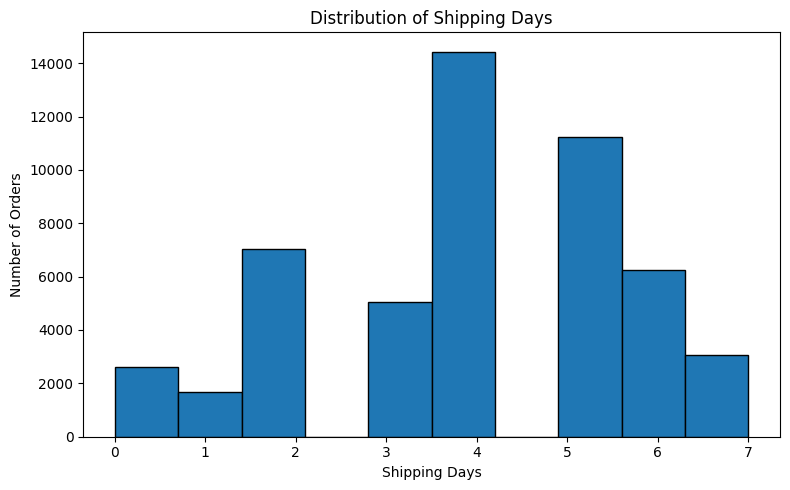

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df["shipping_days"], bins=10, edgecolor="black")
plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#### observation

- Most orders were delivered within a relatively short period.
- Long shipping times occurred only in a small number of transactions.

#### insight

The shipping process appears to be operationally efficient, with the majority of deliveries completed within a few days.

### Shipping mode summary

In [45]:
shipping_mode_summary = (df.groupby("ship_mode", as_index=False).agg(Sales=("sales","sum"), Profit=("profit","sum"), Orders=("order_id","count")).sort_values("Sales", ascending=False))

shipping_mode_summary

,ship_mode,Sales,Profit,Orders
3,Standard Class,7578889.0,890596.02120,30775
2,Second Class,2565747.0,294161.05708,10309
0,First Class,1831067.0,208104.67520,7505
1,Same Day,667202.0,76173.06780,2701


### Shipping Days vs Profit

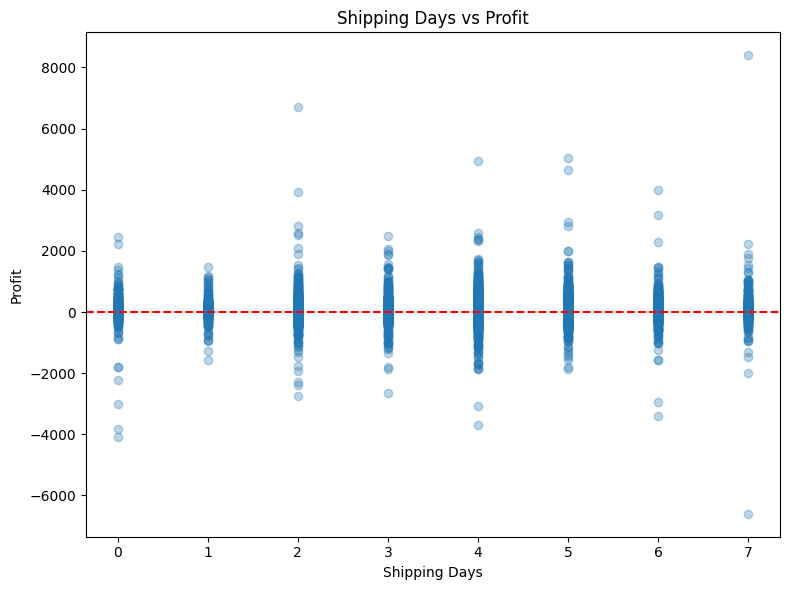

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["shipping_days"],
    df["profit"],
    alpha=0.3
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Shipping Days vs Profit")
plt.xlabel("Shipping Days")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

#### observation

- No clear relationship is observed between shipping time and profit.
- Orders with similar shipping durations show a wide range of profitability.
#### insight

Shipping duration does not appear to be a primary driver of profitability. Product characteristics, pricing strategies, and discount policies are likely to have a greater impact on business performance.

In [47]:
df[["shipping_days","profit"]].corr()

,shipping_days,profit
shipping_days,1.000000,0.001543
profit,0.001543,1.000000


## Correlation Analysis

In [48]:
numerical_cols = ["sales", "profit", "quantity", "discount", "shipping_cost", "shipping_days", "profit_margin"]
corr = df[numerical_cols].corr()
corr

,sales,profit,quantity,discount,shipping_cost,shipping_days,profit_margin
sales,1.000000,0.485944,0.313580,-0.086728,0.768075,-0.004661,0.074710
profit,0.485944,1.000000,0.104743,-0.316375,0.357033,0.001543,0.357199
quantity,0.313580,0.104743,1.000000,-0.019875,0.272649,0.004347,0.050487
discount,-0.086728,-0.316375,-0.019875,1.000000,-0.079056,-0.001507,-0.846445
shipping_cost,0.768075,0.357033,0.272649,-0.079056,1.000000,-0.142823,0.067945
shipping_days,-0.004661,0.001543,0.004347,-0.001507,-0.142823,1.000000,0.000087
profit_margin,0.074710,0.357199,0.050487,-0.846445,0.067945,0.000087,1.000000


#### Key Findings

- Sales and profit show a positive correlation, indicating that higher sales generally contribute to higher profit.
- Discount is negatively correlated with profit, suggesting that larger discounts reduce profitability.
- Shipping days have little correlation with profit, indicating that delivery time is not a major factor affecting financial performance.

In [49]:
df.to_csv("global-superstore-clean.csv", index=False)

# Business Insight
- Sales and profit increased steadily from 2011 to 2014.
- Technology was the strongest-performing category.
- Tables generated losses despite high sales.
- Consumer was the largest customer segment.
- APAC was the highest-performing market.
- High discounts were associated with lower profitability.
- Shipping time showed little impact on profit.

# Business Recomendation
- Review pricing and discount strategies for Tables.
- Increase marketing for high-margin products such as Copiers and Paper.
- Maintain inventory for high-performing products like Phones.
- Expand sales initiatives in high-potential but underperforming regions.
- Monitor discount policies to protect profitability.